# Group project-Simulate wake field
Core Ideas: 

Simulating Wake pattern in low speed (low froude number) regime 

Regime change at higher speed (high froude number) 

Modelling the transition 

## 1. Physical assumptions

We use a simplified linear free-surface model with the following assumptions:

1. The fluid is **incompressible**.
2. The fluid is **inviscid**.
3. The flow is **irrotational**.
4. The water is **deep**.
5. Surface tension is neglected.
6. The disturbance moves at constant speed in a straight line.
7. We focus on the **low-speed / low-Froude-number regime**.

These assumptions are standard for a first Kelvin-wake model and are enough to produce a wake-like interference pattern.

## 2. Basic theory

The Froude number compares inertial and gravitational effects:

$$
Fr = \frac{U}{\sqrt{gL}},
$$

where:
- $U$ is the disturbance speed,
- $L$ is a characteristic length scale,
- $g$ is gravitational acceleration.

For deep-water gravity waves, the dispersion relation is

$$
\omega^2 = gk.
$$

Using the steady-wave condition for a disturbance moving with speed $U$,

$$
\omega = Uk\cos\theta,
$$

cited from (https://www.wikiwaves.org/index.php/Ship_Kelvin_Wake), which gives the allowed wavenumber

$$
k(\theta) = \frac{g}{U^2 \cos^2\theta}.
$$

To mimic a spatially localised pressure source, we apply a Gaussian-type weighting to each angular mode, which was proposed in:(https://www.sciencedirect.com/science/article/pii/S0997754614001137)

$$
A(\theta) = \exp\left[-\frac{(kL)^2}{C}\right],
$$

where $C$ is a tunable constant controlling how strongly short wavelengths are suppressed.

The free-surface elevation is then reconstructed by angular superposition:

$$
\eta(x,y) \propto \int A(\theta)\cos\left(k(\theta)\,[x\cos\theta + y\sin\theta]\right)\, d\theta.
$$

Numerically, this is evaluated by summation over many values of $\theta$.

# 3. Initialisation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
g = 9.81 # gravity (m/s^2)
speed = 1.0 # U (m/s)
length = 1.0 # L (m)
# Computational domain
x = np.linspace(-12, 2, 500)
y = np.linspace(-6, 6, 350)
X, Y = np.meshgrid(x, y)

# Kelvin half-angle
kelvin_angle = np.arcsin(1/3)
print(f"Kelvin half-angle = {np.degrees(kelvin_angle):.2f} degrees")

Kelvin half-angle = 19.47 degrees


## 4. Numerical model

Instead of hard-coding one case, we define a reusable function `wake_field(...)`.
This makes it much easier to compare different Froude numbers and improve the notebook later.

In [14]:
def wake_field(froude_number,g=9.81,length=1.0,X=None,Y=None,
               ntheta=1000,theta_margin=0.02,amplitude_const=40.0,batch_size=200):
    '''
    Construct a simplified Kelvin-like wake field for a chosen Froude number.

    Parameters
    ----------
    froude_number : float
        Froude number Fr = U / sqrt(gL).
    g : float
        Gravitational acceleration.
    length : float
        Characteristic disturbance length L.
    X, Y : 2D arrays
        Meshgrid arrays defining the computational domain.
    ntheta : int
        Number of angular samples.
    theta_margin : float
        Small cutoff to avoid divergence near cos(theta)=0.
    amplitude_const : float
        Controls Gaussian suppression of high-k modes.
    batch_size : int
        Number of angular modes processed together for efficiency.

    Returns
    -------
    eta : 2D array
        Simulated surface elevation.
    speed : float
        Disturbance speed corresponding to the Froude number.
    theta : 1D array
        Angular grid.
    k : 1D array
        Allowed wavenumber for each theta.
    A : 1D array
        Amplitude weighting.
    '''
    if X is None or Y is None:
        raise ValueError("X and Y must be provided.")

    speed = froude_number * np.sqrt(g * length)

    theta = np.linspace(-np.pi/2 + theta_margin, np.pi/2 - theta_margin, ntheta)
    dtheta = theta[1] - theta[0]

    # Allowed wavenumber from deep-water gravity-wave dispersion
    k = g / (speed**2 * np.cos(theta)**2)

    # Gaussian-inspired weighting
    A = np.exp(- (k * length)**2 / amplitude_const)

    eta = np.zeros_like(X, dtype=float)

    # Batch computation to avoid very slow Python loops
    for start in range(0, ntheta, batch_size):
        th = theta[start:start + batch_size][:, None, None]
        kk = k[start:start + batch_size][:, None, None]
        AA = A[start:start + batch_size][:, None, None]

        phase = kk * (X[None, :, :] * np.cos(th) + Y[None, :, :] * np.sin(th))
        eta += np.sum(AA * np.cos(phase), axis=0)

    eta *= dtheta
    return eta, speed, theta, k, A

## 5. A single low-Froude example

We first generate one example wake field to confirm that the model produces the expected wedge-like interference structure behind the disturbance.

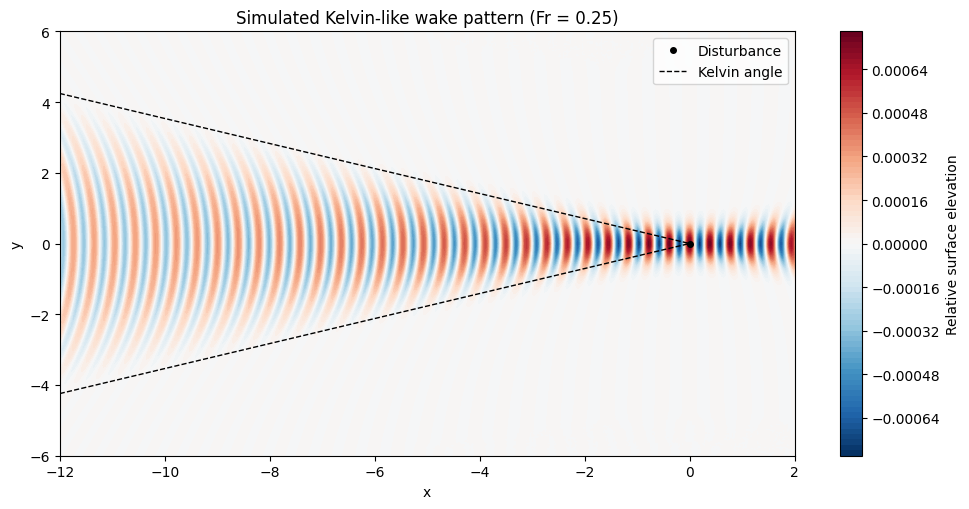

In [15]:
Fr_example = 0.25

eta, speed, theta, k, A = wake_field(
    froude_number=Fr_example,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=1000,
    amplitude_const=40.0,
)

plt.figure(figsize=(10, 5.2))
cf = plt.contourf(X, Y, eta, levels=100, cmap="RdBu_r")
plt.colorbar(cf, label="Relative surface elevation")
plt.plot(0, 0, "ko", ms=4, label="Disturbance")

x_line = np.linspace(x.min(), 0, 300)
y_upper = np.tan(kelvin_angle) * (-x_line)
y_lower = -np.tan(kelvin_angle) * (-x_line)
plt.plot(x_line, y_upper, "k--", lw=1, label="Kelvin angle")
plt.plot(x_line, y_lower, "k--", lw=1)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Simulated Kelvin-like wake pattern (Fr = {Fr_example:.2f})")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

This first figure already shows a wake-like pattern concentrated behind the disturbance.
We now compare several low-Froude cases systematically.

## 6. Parameter scan over Froude number

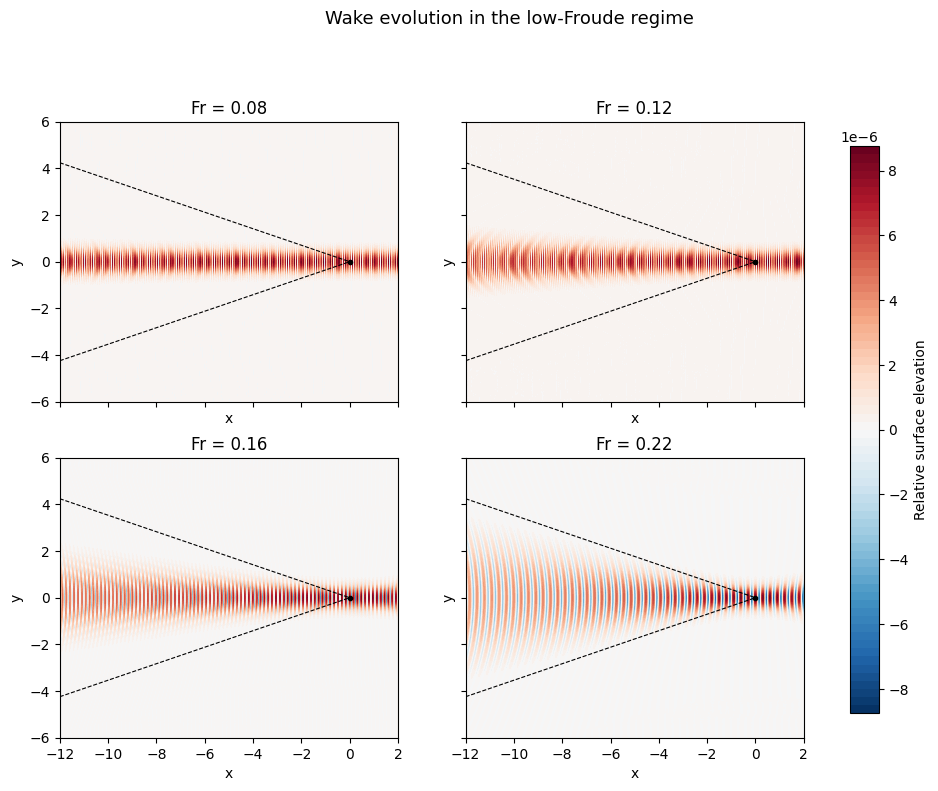

In [23]:
low_fr_values = [0.08, 0.12, 0.16, 0.22]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, Fr in zip(axes.flat, low_fr_values):
    eta, speed, theta, k, A = wake_field(
        froude_number=Fr,
        g=g,
        length=length,
        X=X,
        Y=Y,
        ntheta=900,
        amplitude_const=40.0,
    )

    cf = ax.contourf(X, Y, eta, levels=80, cmap="RdBu_r")
    ax.plot(0, 0, "ko", ms=3)

    x_line = np.linspace(x.min(), 0, 300)
    y_upper = np.tan(kelvin_angle) * (-x_line)
    y_lower = -np.tan(kelvin_angle) * (-x_line)
    ax.plot(x_line, y_upper, "k--", lw=0.8)
    ax.plot(x_line, y_lower, "k--", lw=0.8)

    ax.set_title(f"Fr = {Fr:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.colorbar(cf, ax=axes.ravel().tolist(), shrink=0.92, label="Relative surface elevation")
plt.suptitle("Wake evolution in the low-Froude regime", y=1.02, fontsize=13)
plt.show()

### Interpretation of the parameter scan

As the Froude number changes:
- the spacing of the interference pattern changes,
- the concentration of oscillations near the centreline changes,
- the apparent wake structure becomes more or less compressed.

This is physically reasonable because the allowed wavenumber depends on speed through

$$
k(\theta) = \frac{g}{U^2 \cos^2\theta},
$$

so changing $Fr$ directly changes the wavelength content of the reconstructed wake.

## 7. Centreline cut

We plot the wake signal along the centreline $y=0$. The centreline cut is introduced to provide a clearer and more quantitative view of the wake signal than the two-dimensional contour plot alone. By plotting the free-surface elevation along
$y=0$, the complex wake field is reduced to a one-dimensional oscillatory profile, making it easier to identify the spacing, amplitude, and downstream variation of the waves. 

The alternating peaks and troughs confirm that the simulated wake arises from the interference of multiple angular wave contributions. In addition, the larger amplitude close to the disturbance and the weaker oscillations further downstream indicate that the wake energy is spatially concentrated rather than uniformly distributed. 

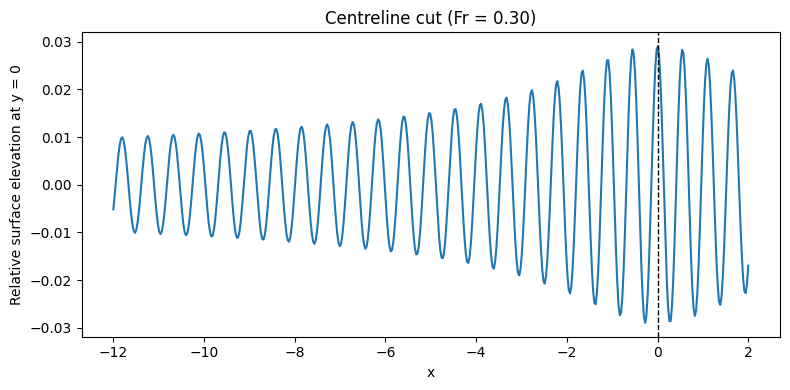

In [36]:
Fr_cut = 0.30

eta, speed, theta, k, A = wake_field(
    froude_number=Fr_cut,
    g=g,
    length=length,
    X=X,
    Y=Y,
    ntheta=900,
    amplitude_const=40.0,
)

iy0 = np.argmin(np.abs(y))

plt.figure(figsize=(8, 4))
plt.plot(x, eta[iy0, :])
plt.axvline(0, color="k", ls="--", lw=1)
plt.xlabel("x")
plt.ylabel("Relative surface elevation at y = 0")
plt.title(f"Centreline cut (Fr = {Fr_cut:.2f})")
plt.tight_layout()
plt.show()

To investigate the characteristic oscillation spacing, we estimate an **effective wavelength** from the centreline signal by locating successive local maxima in $\eta(x,0)$ and averaging the spacing between them. The function `find_local_maxima_1d` is used to find the excessive maxima and thus determine the wavelength.

In [26]:
def find_local_maxima_1d(arr):
    idx = []
    for i in range(1, len(arr)-1):
        if arr[i] > arr[i-1] and arr[i] > arr[i+1]:
            idx.append(i)
    return np.array(idx, dtype=int)

def effective_wavelength_from_centreline(x, yline, x_max_for_fit=-0.5):
    # restrict to downstream wake region and avoid the immediate source region
    mask = x < x_max_for_fit
    x_use = x[mask]
    y_use = yline[mask]

    max_idx = find_local_maxima_1d(y_use)

    if len(max_idx) < 2:
        return np.nan, x_use, y_use, max_idx

    peak_positions = x_use[max_idx]
    spacings = np.diff(peak_positions)
    return np.mean(np.abs(spacings)), x_use, y_use, max_idx

  0%|          | 0/8 [00:00<?, ?it/s]

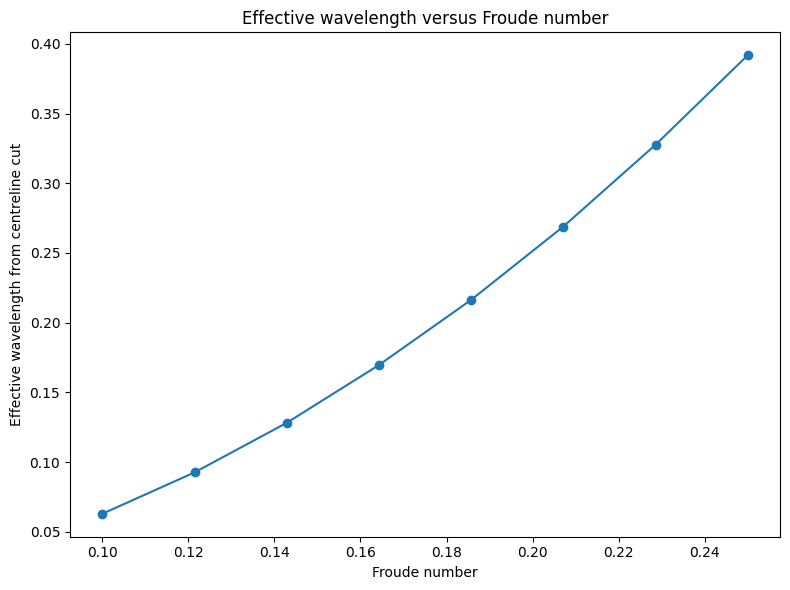

In [35]:
fr_wave = np.linspace(0.10, 0.25, 8)
lambda_eff = []

for Fr in tqdm(fr_wave):
    eta, speed, theta, k, A = wake_field(
        froude_number=Fr,
        g=g,
        length=length,
        X=X,
        Y=Y,
        ntheta=900,
        amplitude_const=40.0,
    )
    iy0 = np.argmin(np.abs(y))
    lam, _, _, _ = effective_wavelength_from_centreline(x, eta[iy0, :], x_max_for_fit=-0.5)
    lambda_eff.append(lam)

plt.figure(figsize=(8, 6))
plt.plot(fr_wave, lambda_eff, marker="o")
plt.xlabel("Froude number")
plt.ylabel("Effective wavelength from centreline cut")
plt.title("Effective wavelength versus Froude number")
plt.tight_layout()
plt.show()

## 8. Quantitative comparison across Froude number

To make the study more analytical, we define simple scalar measures of wake strength:
- the RMS amplitude over the full computational domain,
- the peak absolute amplitude.

<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
C:\temp\ipykernel_7036\4165018375.py:20: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(fr_scan, peak_values, marker="s", label="Peak |$\eta$|")


  0%|          | 0/12 [00:00<?, ?it/s]

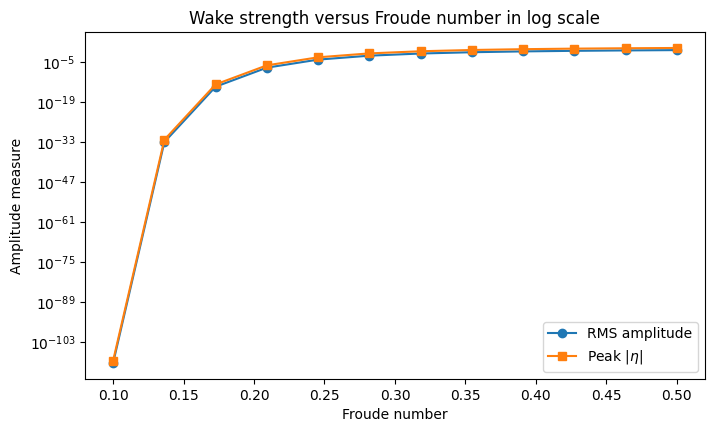

In [37]:
fr_scan = np.linspace(0.10, 0.5, 12)
rms_values = []
peak_values = []

for Fr in tqdm(fr_scan):
    eta, speed, theta, k, A = wake_field(
        froude_number=Fr,
        g=g,
        length=length,
        X=X,
        Y=Y,
        ntheta=800,
        amplitude_const=40.0,
    )
    rms_values.append(np.sqrt(np.mean(eta**2)))
    peak_values.append(np.max(np.abs(eta)))

plt.figure(figsize=(8, 4.5))
plt.plot(fr_scan, rms_values, marker="o", label="RMS amplitude")
plt.plot(fr_scan, peak_values, marker="s", label="Peak |$\eta$|")
plt.xlabel("Froude number")
plt.ylabel("Amplitude measure")
plt.title("Wake strength versus Froude number in log scale")
plt.yscale("log")
plt.legend()
plt.show()

## 9. Effect of resolution of theta angle

This convergence check tests whether the centreline signal is sensitive to the angular resolution used in the numerical integration.

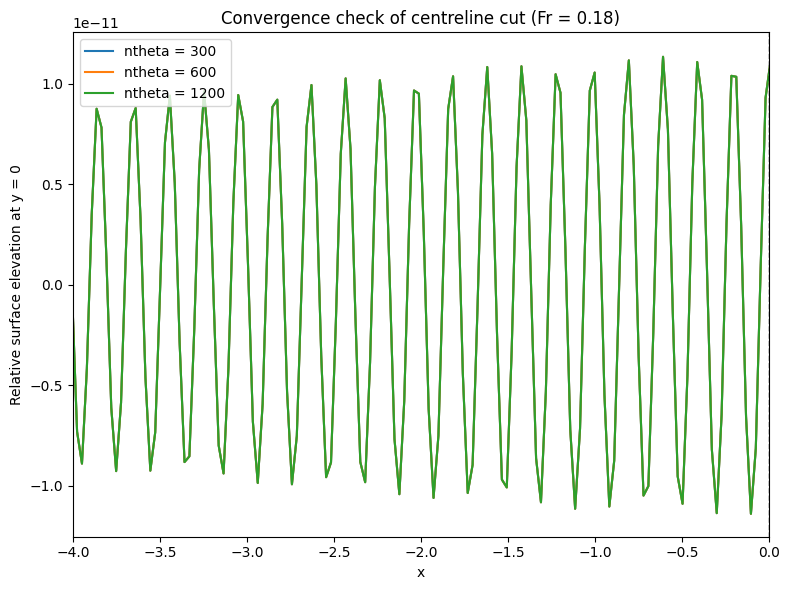

In [30]:
Fr_conv = 0.18
ntheta_values = [300, 600, 1200]

plt.figure(figsize=(8, 6))

for ntheta in ntheta_values:
    eta, speed, theta, k, A = wake_field(
        froude_number=Fr_conv,
        g=g,
        length=length,
        X=X,
        Y=Y,
        ntheta=ntheta,
        amplitude_const=40.0,
    )
    iy0 = np.argmin(np.abs(y))
    plt.plot(x, eta[iy0, :], label=f"ntheta = {ntheta}")

plt.axvline(0, color="k", ls="--", lw=1)
plt.xlabel("x")
plt.ylabel("Relative surface elevation at y = 0")
plt.xlim(-4,0)
plt.title(f"Convergence check of centreline cut (Fr = {Fr_conv:.2f})")
plt.legend()
plt.tight_layout()
plt.show()

The curves for $n_\theta=300,600,1200$ lie almost exactly on top of each other, showing that the oscillatory wake structure is numerically stable with respect to angular discretisation. This indicates that the peak positions, wavelength-like spacing, and overall waveform are not artifacts of insufficient sampling in $\theta$. Although the result is numerically converged, the absolute amplitude remains extremely small, suggesting that the current Gaussian weighting strongly suppresses the wake signal in this low-Froude regime.

Because $k(\theta)$ grows strongly as $\cos\theta \to 0$, we also want to avoid sampling exactly at $\pm\pi/2$.
This introduces a small numerical parameter, `theta_margin`, which should also be checked.

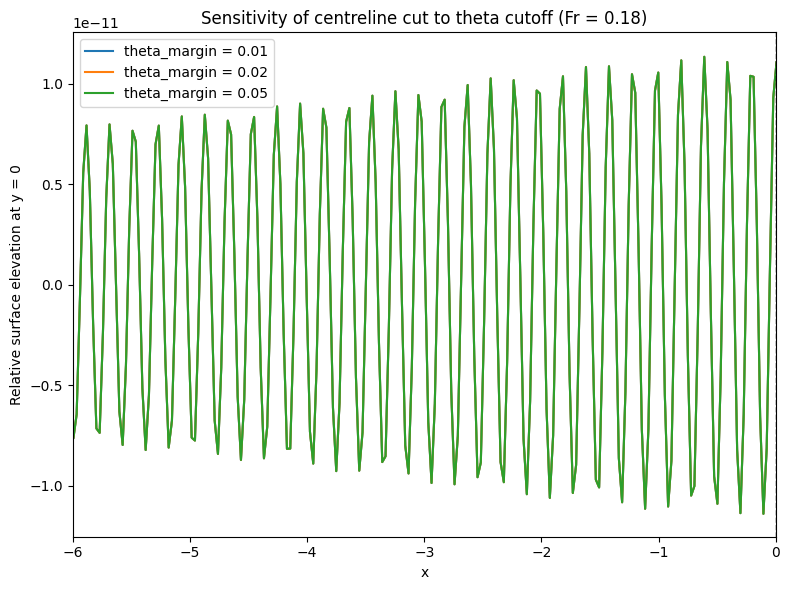

In [34]:
Fr_margin = 0.18
theta_margins = [0.01, 0.02, 0.05]

plt.figure(figsize=(8, 6))

for margin in theta_margins:
    eta, speed, theta, k, A = wake_field(
        froude_number=Fr_margin,
        g=g,
        length=length,
        X=X,
        Y=Y,
        ntheta=900,
        theta_margin=margin,
        amplitude_const=40.0,
    )
    iy0 = np.argmin(np.abs(y))
    plt.plot(x, eta[iy0, :], label=f"theta_margin = {margin}")

plt.axvline(0, color="k", ls="--", lw=1)
plt.xlabel("x")
plt.ylabel("Relative surface elevation at y = 0")
plt.xlim(-6,0)
plt.title(f"Sensitivity of centreline cut to theta cutoff (Fr = {Fr_margin:.2f})")
plt.legend()
plt.tight_layout()
plt.show()

The predicted oscillatory structure is stable over a reasonable range of cutoff values. This suggests that the main wake pattern is not dominated by contributions from the nearly singular angular region